<a href="https://colab.research.google.com/github/ANASSHAIKH-NOOB/AI-PROJECT/blob/main/PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1: Problem Understanding & Data Collection

## 1. Project Title
**HealTrack Pakistan: Data-Driven Stratification and Capacity Modeling of National Healthcare Infrastructure**

## 2. Background Context & Local Importance
Healthcare resource distribution across Pakistan’s 5,500 public and private institutions exhibits deep systemic disparities. While tier-1 metropolitan cities feature a dense footprint of advanced clinical assets, regional districts and rural facilities frequently face critical shortages of operational beds, specialized personnel, and emergency gear.

Manual auditing of these facility frameworks by provincial health departments is slow and prone to oversight. This project implements a predictive Machine Learning classification architecture using 37 key infrastructure and human resource variables to dynamically tier healthcare operations, quickly highlighting vulnerable, under-resourced units across Pakistan's provinces.

## 3. Data Collection Summary
- **Source Platform:** Kaggle Registry (Open-Source Research Database)
- **Dataset Identification:** Healthcare Accessibility and Quality in Pakistan
- **Dataset Volume:** 5,500 Real-World/Simulated Institutional Logs
- **Feature Depth:** 37 Structural Variables (Mapping Capacity, Staffing Density, Logistics, and Regional Financial Profiles)

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

In [7]:
drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/pakistan_healthcare_dataset.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Connection Established Successfully!
Dataset Grid Size: 5500 Records (Rows) | 37 Variables (Columns)



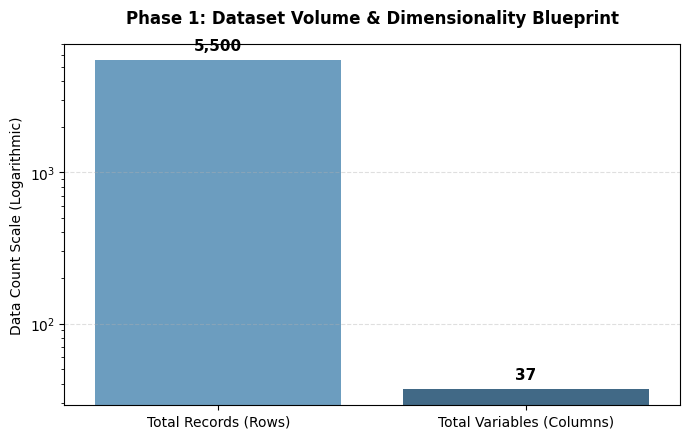

In [13]:
try:
    # 3. Load the dataset
    df = pd.read_csv(file_path)
    df.head()
    rows, cols = df.shape

    print("Connection Established Successfully!")
    print(f"Dataset Grid Size: {rows} Records (Rows) | {cols} Variables (Columns)\n")

    # 4. Compulsory Phase 1 Visualization: Dataset Structural Footprint
    plt.figure(figsize=(7, 4.5))
    metrics = ['Total Records (Rows)', 'Total Variables (Columns)']
    values = [rows, cols]

    # Added hue=metrics and legend=False to resolve the deprecation warning cleanly
    ax = sns.barplot(x=metrics, y=values, hue=metrics, palette="Blues_d", legend=False)
    plt.yscale('log')

    # Inject data label value counts on top of bars
    for p in ax.patches:
        ax.annotate(f"{int(p.get_height()):,}",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=11, fontweight='bold', color='black', xytext=(0, 5),
                    textcoords='offset points')

    plt.title("Phase 1: Dataset Volume & Dimensionality Blueprint", fontsize=12, fontweight='bold', pad=15)
    plt.ylabel("Data Count Scale (Logarithmic)", fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("Critical Error: CSV file not detected.")
    print("Please check your file path directory. Ensure the file is saved inside your Google Drive folder and matches your file path string exactly.")

In [14]:
df.describe()

,Year,Total_Beds,ICU_Beds,Operation_Theatres,Medical_Equipment_Score,Total_Doctors,Specialists,Nurses,Paramedical_Staff,Doctor_Patient_Ratio,...,Consultation_Fee,Surgery_Cost,Government_Funding,Patient_Satisfaction_Score,Mortality_Rate,Infection_Rate,Readmission_Rate,Waiting_Time_Minutes,Distance_from_City_Center,Rural_Patients_Percentage
count,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,...,5500.000000,5500.000000,5.500000e+03,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000
mean,2022.993455,778.085636,103.098000,10.561273,6.495927,204.124182,78.079273,407.304545,153.006182,0.001254,...,1591.685818,100498.496909,1.261833e+07,7.303364,2.761956,3.803693,5.462524,92.940000,20.473145,42.873636
std,0.821798,421.763835,56.944772,5.765187,1.435121,113.267187,42.203413,226.337984,84.731067,0.000434,...,1480.379706,82416.569119,1.607403e+07,1.296729,1.311199,1.881684,2.610493,50.459439,11.324433,21.769959
min,2022.000000,50.000000,5.000000,1.000000,4.000000,10.000000,5.000000,20.000000,10.000000,0.000500,...,100.000000,5052.000000,0.000000e+00,5.000000,0.500000,0.500000,1.000000,5.000000,1.000000,5.000000
25%,2022.000000,408.000000,54.000000,6.000000,5.300000,107.000000,41.000000,214.000000,78.000000,0.000882,...,444.750000,38887.000000,0.000000e+00,6.200000,1.610000,2.170000,3.170000,51.000000,10.400000,24.000000
50%,2023.000000,782.000000,104.000000,11.000000,6.500000,204.000000,78.000000,404.000000,152.000000,0.001257,...,755.500000,67431.000000,1.588858e+06,7.300000,2.770000,3.860000,5.430000,93.000000,20.700000,43.000000
75%,2024.000000,1145.000000,152.000000,16.000000,7.700000,302.000000,115.000000,603.000000,227.000000,0.001634,...,2736.250000,156194.000000,2.494127e+07,8.400000,3.910000,5.430000,7.732500,136.000000,30.200000,62.000000
max,2024.000000,1500.000000,200.000000,20.000000,9.000000,400.000000,150.000000,800.000000,300.000000,0.002000,...,4995.000000,299953.000000,4.998359e+07,9.500000,5.000000,7.000000,10.000000,180.000000,40.000000,80.000000


# Phase 2: Variable & Feature Definition

## 1. Target Variable Definition
Because this public registry tracks hospital capacities but does not include a pre-labeled classification column, we mathematically engineer our ground truth target column: **`Target_Capability_Tier`**.
- **Type:** Binary Categorical (`int64` representation: `0` or `1`)
- **Class 1 (High-Capability Hub):** Represents a fully equipped medical facility containing active ICU assets and a functional Emergency Department.
- **Class 0 (Under-Resourced Care Unit):** Represents a facility lacking critical critical care infrastructure, designating it as a priority for resource allocation.

## 2. Predictor Feature Groups (36 Columns total mapped into 4 Operational Vectors)
To ensure clean processing during our upcoming multi-criteria feature selection phases, the variables are grouped logically:

### A. Spatial & Structural Demographics
- `Sector` (Public vs. Private ownership)
- `City` & `Province` (Geographical distribution markers across Pakistan)
- `Hospital_Type` (General, Teaching, or Specialized)
- `Distance_from_City_Center` (Logistical accessibility in kilometers)

### B. Core Capacity & Infrastructure Assets
- `Total_Beds` & `ICU_Beds` (Physical volume thresholds)
- `Operation_Theatres` (Surgical deployment capability)
- `Emergency_Department` & `Diagnostic_Labs` (Presence indicators: Yes/No)
- `Medical_Equipment_Score` (Quality index score of clinical machinery)

### C. Human Resource & Staffing Footprint
- `Total_Doctors` & `Specialists` (Clinical expertise density)
- `Nurses` & `Paramedical_Staff` (Nursing and support care bandwidth)
- `Doctor_Patient_Ratio` (Calculated workload coefficient)

### D. Operational Loads & Financial Metrics
- `Daily_Outpatients`, `Monthly_Admissions`, `Surgeries_Per_Month`, `Emergency_Cases` (Patient volume metrics)
- `Average_Treatment_Cost`, `Consultation_Fee`, `Surgery_Cost` (Financial barriers to access)
- `Government_Funding` (State financial support in PKR)
- `Rural_Patients_Percentage` (Socio-demographic exposure indicator)

--- Native Dataset Data Type Profile ---
Data Type: int64 | Total Columns: 18
Data Type: object | Total Columns: 11
Data Type: float64 | Total Columns: 8


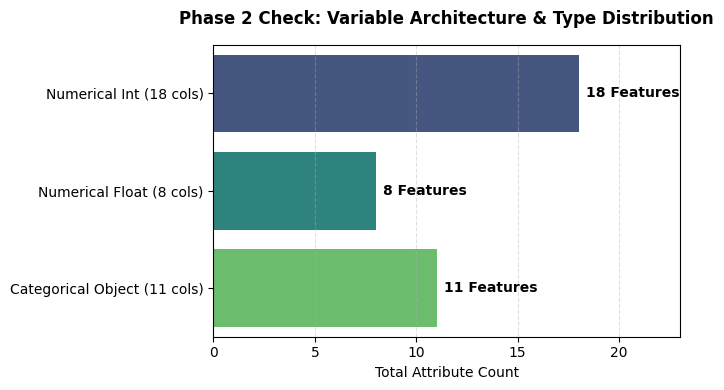

In [15]:
# Profile Data Types across all 37 native columns
dtype_counts = df.dtypes.value_counts()

print("--- Native Dataset Data Type Profile ---")
for dtype, count in dtype_counts.items():
    print(f"Data Type: {dtype} | Total Columns: {count}")

# Compulsory Phase 2 Visual: Bar Chart of Feature Type Distributions
plt.figure(figsize=(7, 4))

labels = [f"Numerical Int ({df.select_dtypes(include=['int64']).shape[1]} cols)",
          f"Numerical Float ({df.select_dtypes(include=['float64']).shape[1]} cols)",
          f"Categorical Object ({df.select_dtypes(include=['object']).shape[1]} cols)"]
counts = [df.select_dtypes(include=['int64']).shape[1],
          df.select_dtypes(include=['float64']).shape[1],
          df.select_dtypes(include=['object']).shape[1]]

# Added hue=labels and legend=False to suppress warning parameters
ax = sns.barplot(x=counts, y=labels, hue=labels, palette="viridis", orient='h', legend=False)

# Annotate each bar with its exact column count value
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f"{int(width)} Features",
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=10, fontweight='bold', color='black', xytext=(5, 0),
                textcoords='offset points')

plt.title("Phase 2 Check: Variable Architecture & Type Distribution", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Total Attribute Count", fontsize=10)
plt.xlim(0, max(counts) + 5)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()